In [18]:
# adding the Path
push!(LOAD_PATH, "LightModels/")

4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "LightModels/"

# Including base

In [19]:
# including packages
using LazyGrids, PyPlot, BenchmarkTools
using PSFModels, ImageFiltering
using CairoMakie
include("LensBase.jl")
include("LensUtils.jl")
include("LensFITS.jl")
include("LensGenerator.jl")
include("LightModels/GaussianLight.jl")

Main.GaussianLight

## Source Grid

In [20]:
x = range(-2, 2, 51)
xg, yg = LazyGrids.ndgrid(x,x)

([-2.0 -2.0 … -2.0 -2.0; -1.92 -1.92 … -1.92 -1.92; … ; 1.92 1.92 … 1.92 1.92; 2.0 2.0 … 2.0 2.0], [-2.0 -1.92 … 1.92 2.0; -2.0 -1.92 … 1.92 2.0; … ; -2.0 -1.92 … 1.92 2.0; -2.0 -1.92 … 1.92 2.0])

In [8]:
include("LensModels/NIE.jl")

Main.NIE

In [12]:
# The Lensed Plane of Grids
LensParaDict = Dict(:b => 1., :s => 0.1,
 :q => 0.7, :varphi =>  - pi/6. ,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LensBase.LensPlane(xg, yg; LensModel=NIE.NIEkappa, LensKwargs=LensParaDict)

Matrix{Float64}(51, 51)Float64()Matrix{Float64}(51, 51)Float64()

([-1.1718478826934946 -1.158584079131641 … -1.2422804958691487 -1.2606660215590435; -1.105653387903697 -1.0921497358285253 … -1.1807246110684289 -1.1994197070388202; … ; 1.2508855945756383 1.2315774568955389 … 1.129631253141222 1.1436578394805466; 1.3094860394286143 1.2903913036372976 … 1.193996667104447 1.207829673392825], [-1.1150937052809258 -1.0502497394925256 … 1.1388161969775266 1.1981631912244664; -1.1018381150558514 -1.0367380186148325 … 1.1200796232095973 1.179818723594972; … ; -1.1328809137256648 -1.0719085614109511 … 1.0019055922307 1.067796123180829; -1.1518159986158425 -1.0913816177454738 … 1.0160081059067805 1.0815556944288853])

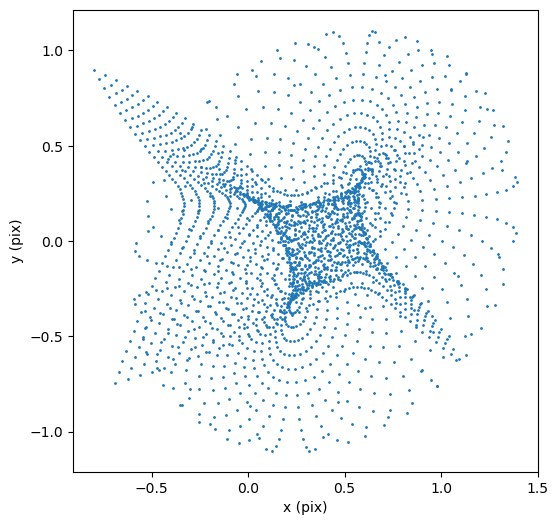

In [195]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
PyPlot.gcf()

In [196]:
clf()

# Image simulation

In [197]:
typeof(xg)

LazyGrids.GridSL{Float64, 1, 2, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}}

In [198]:
# Light Parameters
LightParaDict = Dict(:amp=>1., :sigma=>0.1,
                :xcentre=>0.03, :ycentre=>0.0)
# Gaussian Light Profile
SourceLight = GaussianLight.GaussianSphere(xg, yg; LightParaDict...);

## Gaussian Source

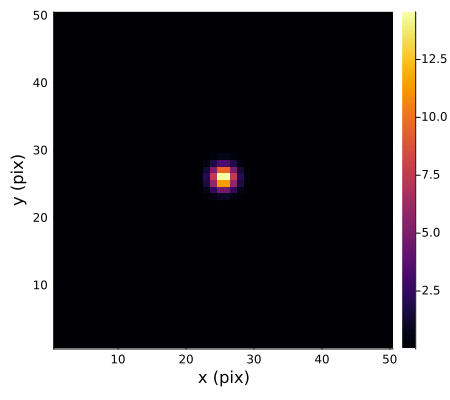

In [199]:
Plots.heatmap(SourceLight, size=(450,400), colorbar=true, xlabel="x (pix)", ylabel="y (pix)")

In [200]:
Lensed = GaussianLight.GaussianSphere(betax, betay; LightParaDict...);

In [201]:
Float64 <: Real

true

In [10]:
array_x = [
    [1  1 1 1];
    [2 2 2 2];
    [3 3 3 3];
]

3×4 Matrix{Int64}:
 1  1  1  1
 2  2  2  2
 3  3  3  3

In [ ]:
flat_x = [1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3];

In [22]:
array_x .- flat_x

LoadError: DimensionMismatch: arrays could not be broadcast to a common size; got a dimension with lengths 3 and 16

# Critical curve and Caustic

In [202]:
csx, csy =  LensBase.LensCaustic(LensModel=NIE, LensKwargs=LensParaDict, hperr=0.01)
ccx, ccy = LensBase.LensCriticalCurve(LensModel=NIE, LensKwargs=LensParaDict, hperr=0.01, r_max=2.5)

([0.7369592398099525, 2.228582145536384, 2.2292073018254563, 2.2298324581145286, 2.230457614403601, 2.231082770692673, 2.2317079269817452, 2.232333083270818, 2.23295823955989, 2.2335833958489624  …  2.242335583895974, 2.242960740185046, 2.2435858964741184, 2.2442110527631907, 2.244836209052263, 2.2454613653413356, 2.246086521630408, 2.24671167791948, 2.2473368342085522, 2.2479619904976245], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  -4.51242075154695e-16, -4.513951942843708e-16, -4.515483134140465e-16, -4.517014325437224e-16, -4.518545516733982e-16, -4.520076708030742e-16, -4.5216078993275e-16, -4.523139090624257e-16, -4.524670281921016e-16, -4.526201473217774e-16])

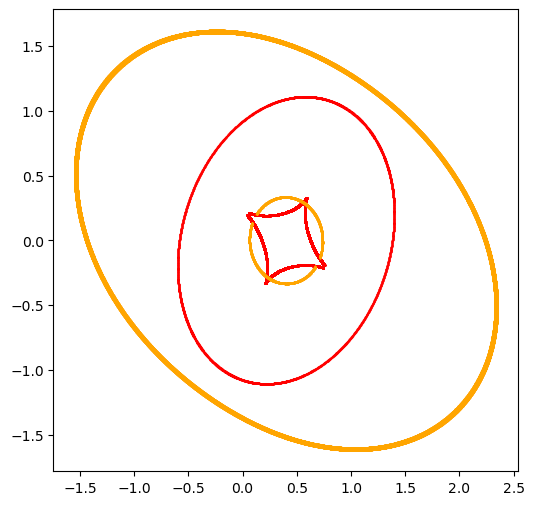

In [300]:

#L1 = Plots.heatmap(x, x, Lensed, size=(450,400), colorbar=true, xlabel="x (pix)", ylabel="y (pix)")
L2 = PyPlot.scatter(csx, csy, s=0.1,  c="red")
L2 = PyPlot.scatter(ccx, ccy, s=0.1,  c="orange")
gcf()

In [239]:
clf()

## Magnification Map

In [204]:
# Lens Reverese LensMagnification
magr = LensBase.LensMagnificationR(xg, yg; LensModel=NIE, LensKwargs=LensParaDict);

## Lensed Images

In [205]:
LightParaDict = Dict(:amp=>1., :sigma=>0.1,
                :xcentre=>0.0, :ycentre=>0.0)
LensParaDict = Dict(:b => 1., :s => 0.1,
 :q => 0.7, :varphi =>  - pi/6. ,
  :xcentre => 0.1, :ycentre => .0);

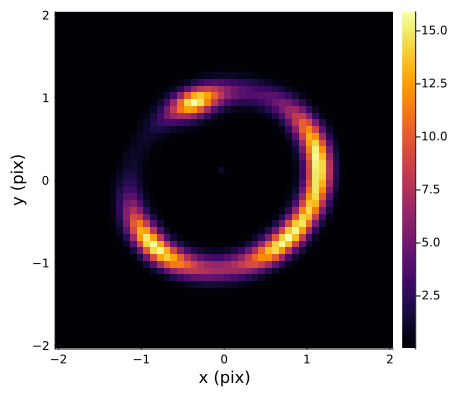

In [206]:
# Simulate the lensed image
LensedLight = LensBase.LensRayShooting(xg, yg; LensModel=NIE, LensKwargs=LensParaDict
                            ,SourceProfile=GaussianLight.GaussianSphere,SourceKwargs=LightParaDict);

L2 = Plots.heatmap(x, x, LensedLight, size=(450,400), colorbar=true, xlabel="x (pix)", ylabel="y (pix)")

In [207]:
PyPlot.clf()

# extented source MCMC

In [208]:
using Turing
using Distributions
using Plots
using StatsPlots
using PairPlots
using CairoMakie

In [225]:
LightParaDict = Dict(:amp=>1., :sigma=>0.1,
                :xcentre=>0.0, :ycentre=>0.0)
LensParaDict = Dict(:b => 1., :s => 0.05,
 :q => 0.7, :varphi =>  - pi/6. ,
  :xcentre => .1, :ycentre => .0);
Target = LensBase.LensRayShooting(xg, yg; LensModel=NIE, LensKwargs=LensParaDict
                            ,SourceProfile=GaussianLight.GaussianSphere,SourceKwargs=LightParaDict);

σ_noise = 0.5
data_obs = Target .+ rand(Normal(0, σ_noise), size(Target))

@model function fit_lensed(x, y, data_obs)
    # Priors for parameters
    
    b ~ truncated(Normal(1., 1), 0, 5)
    s  ~ truncated(Normal(0., 1), 0, 0.1)
    q  ~ truncated(Normal(0.5, 1.0), 0.1, 1)
    varphi ~ truncated(Normal(-pi/6, 1), -pi, pi)
    xcentre ~ truncated(Normal(0, 1), -0.2, 0.2)
    ycentre ~ truncated(Normal(0, 1), -0.2, 0.2)
    σ_noise ~ truncated(Normal(1, 1), 0, 5)
    #print(q)
    
    ParaDict = Dict(:b => b, :s => s,
                :q => q, :varphi =>  varphi,
                :xcentre => xcentre, :ycentre => ycentre);

    # model
    model_intensity = LensBase.LensRayShooting(x, y; LensModel=NIE, LensKwargs=ParaDict,
                        SourceProfile=GaussianLight.GaussianSphere, SourceKwargs=LightParaDict);

    # Likelihood
    for i in eachindex(data_obs)
        if data_obs[i] > mean(data_obs)/3
            data_obs[i] ~ Normal(model_intensity[i], σ_noise)
        end
    end
end

fit_lensed (generic function with 2 methods)

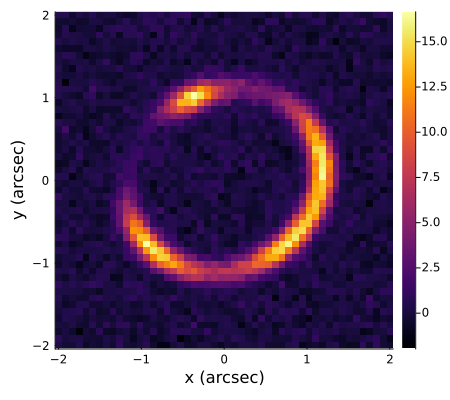

In [226]:
Plots.heatmap(x, x, data_obs, size=(450,400), colorbar=true, xlabel="x (arcsec)", ylabel="y (arcsec)")

In [227]:
# Perform sampling
chain = sample(fit_lensed(xg, yg, data_obs),  NUTS(500,0.65), 1000) #NUTS(400,0.65),  MCMCThreads(), 1000, 4

Chains MCMC chain (1000×19×1 Array{Float64, 3}):

Iterations        = 501:1:1500
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 390.94 seconds
Compute duration  = 390.94 seconds
parameters        = b, s, q, varphi, xcentre, ycentre, σ_noise
internals         = lp, n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size

Summary Statistics
  parameters      mean       std      mcse    ess_bulk   ess_tail      rhat    ⋯
      Symbol   Float64   Float64   Float64     Float64    Float64   Float64    ⋯

           b    1.0018    0.0039    0.0001    880.0075   712.4143    1.0006    ⋯
           s    0.0515    0.0045    0.0001   1006.9495   699.8792    1.0000    ⋯
           q    0.7013    0.0015    0.0001    785.1279   624.0440    1.0009    ⋯
      varphi    2.6163    0.0026    0.0001    788.3685   693.8099    1.0030    ⋯
     xcentre    0.1002    0.

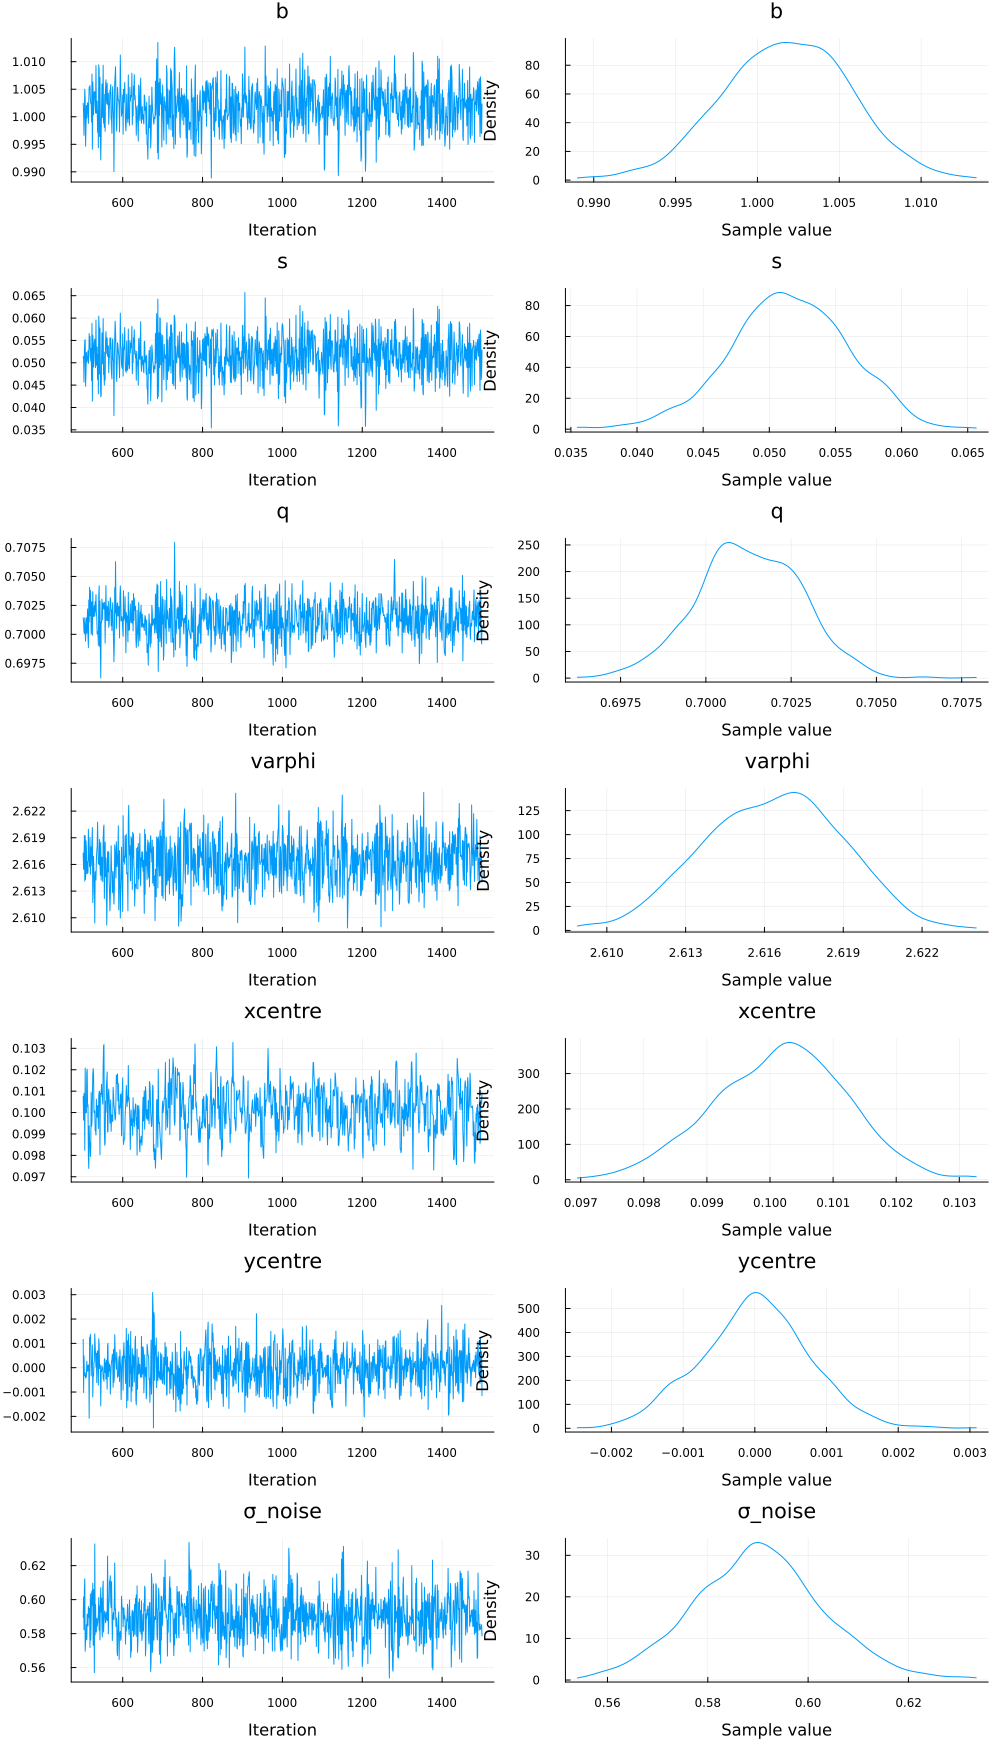

In [228]:
ChainPlot = StatsPlots.plot(chain)

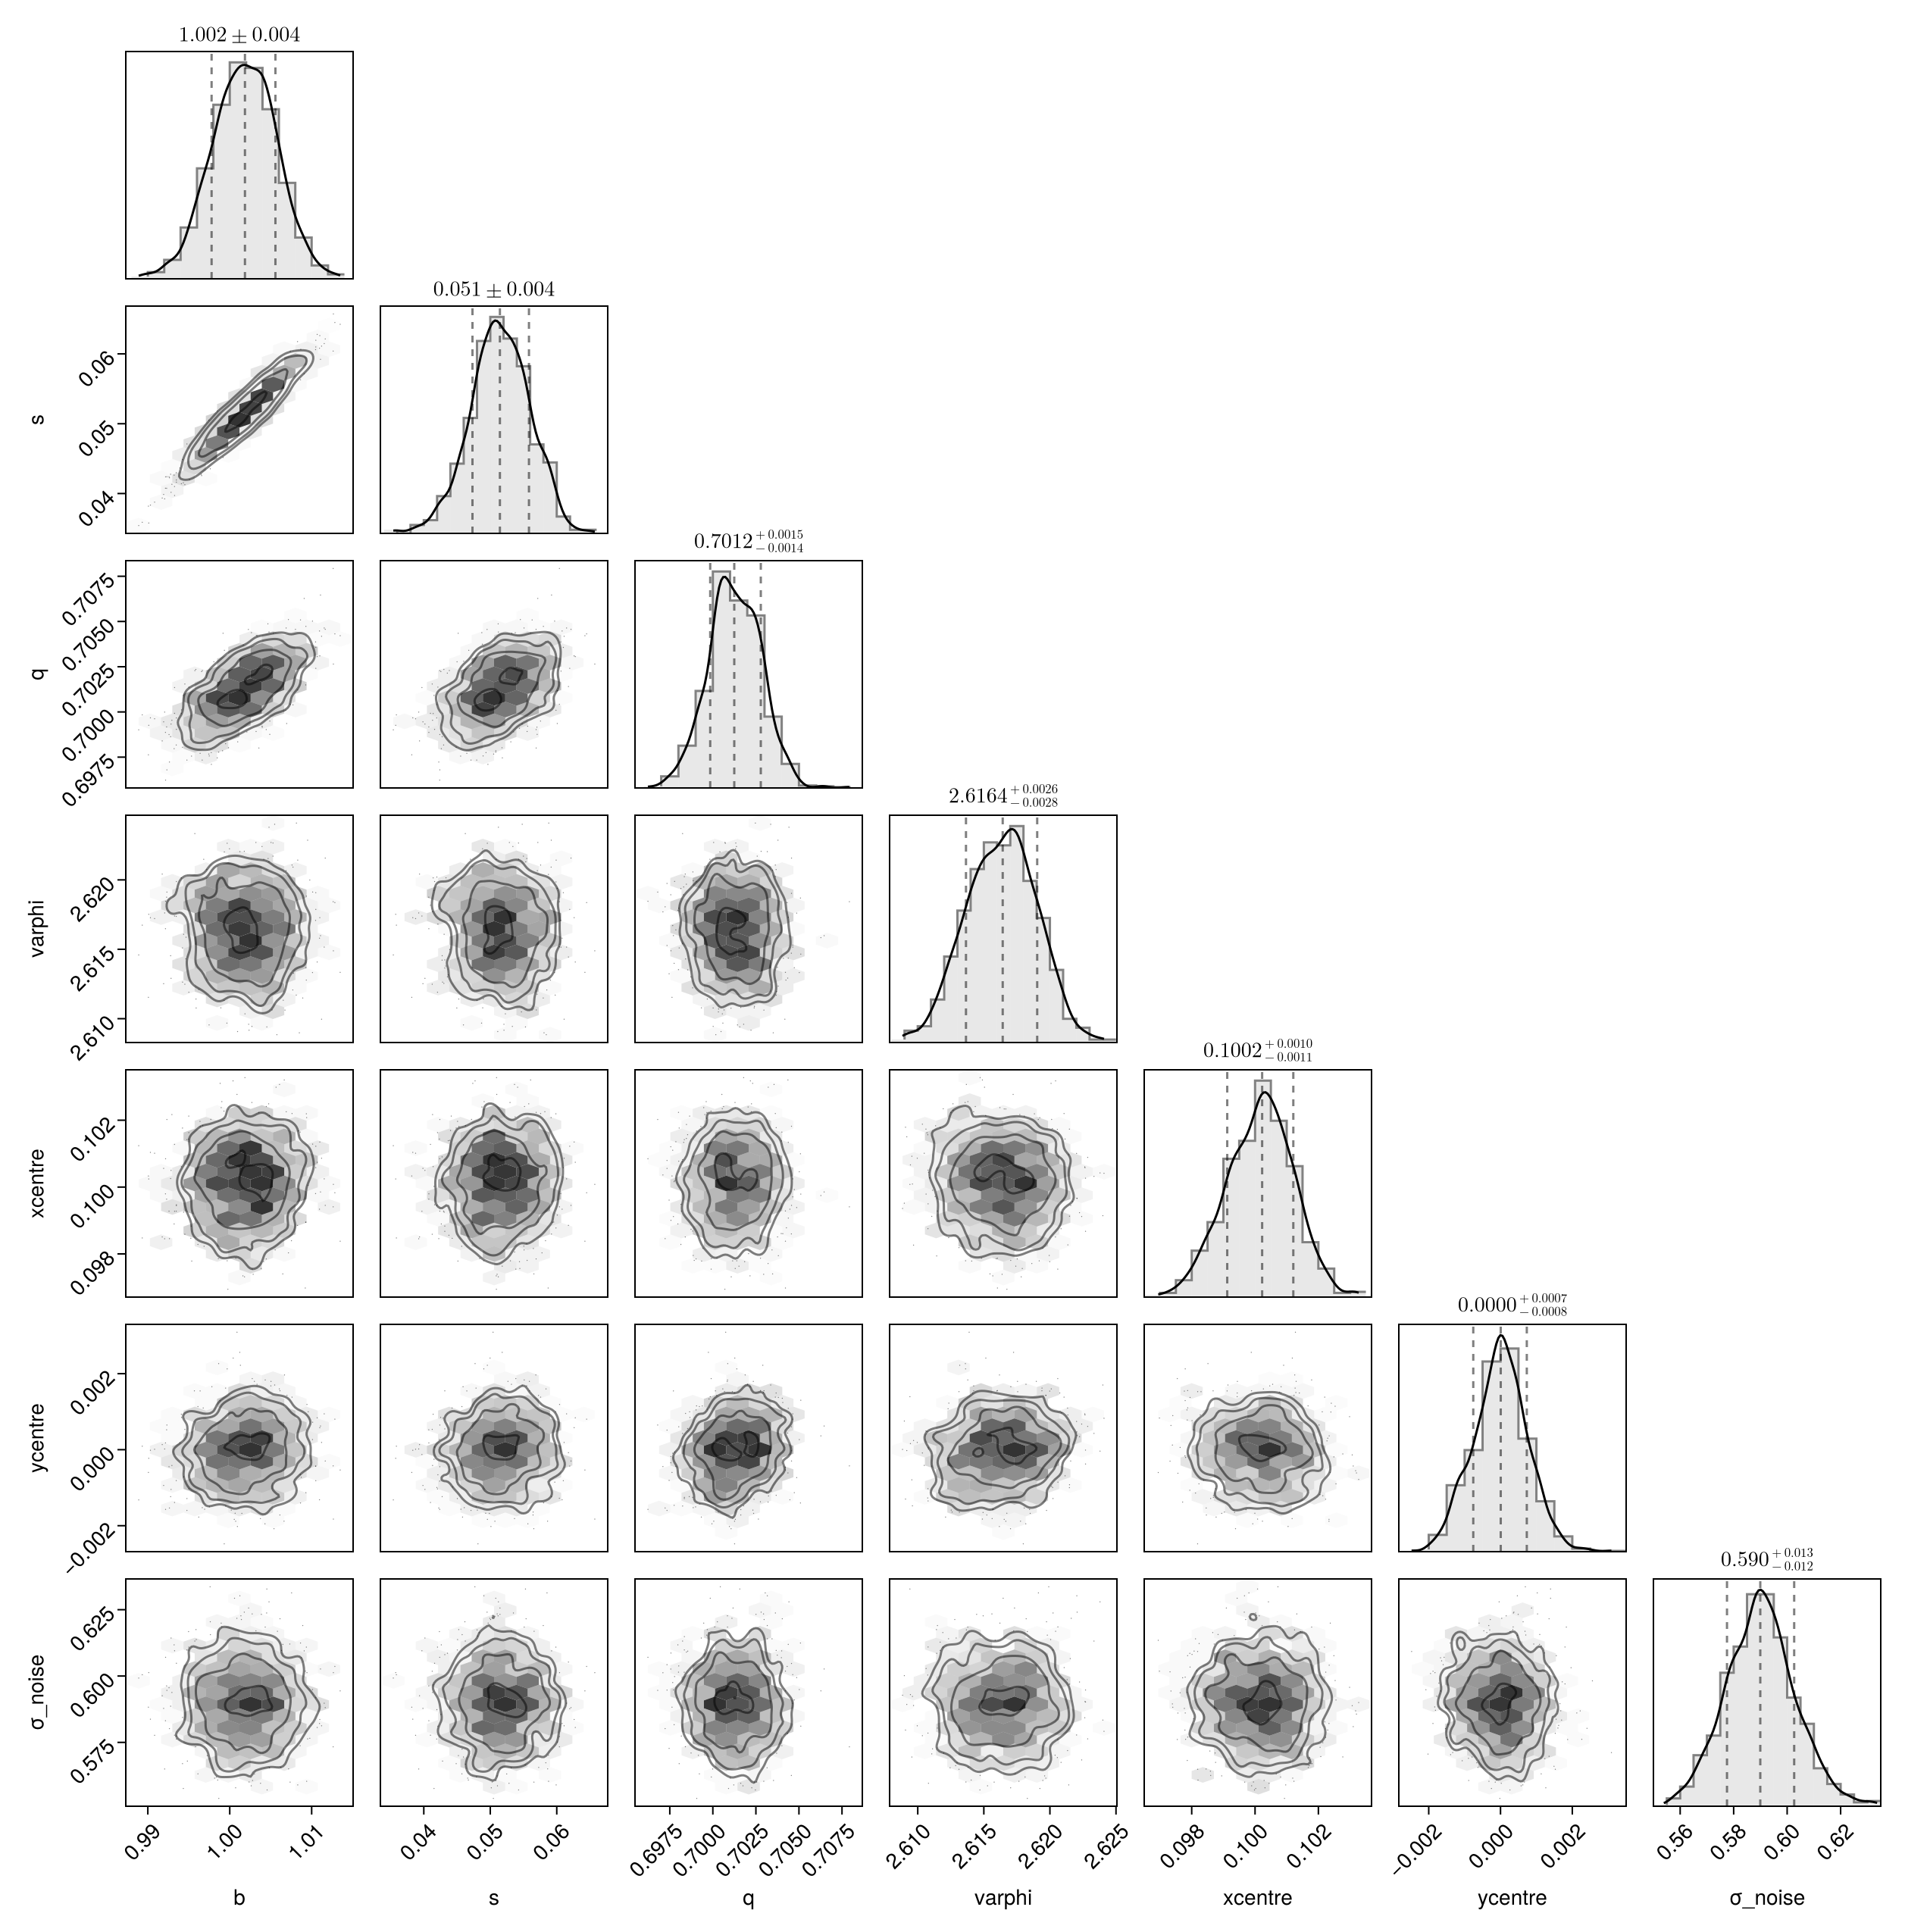

In [230]:
corner_fig = PairPlots.pairplot(chain)

In [271]:
mean_param = Dict([])
para_names = chain.name_map.parameters
for i in range(1,6)
    mean_param[para_names[i]] = mean(chain[:,i,1])
end

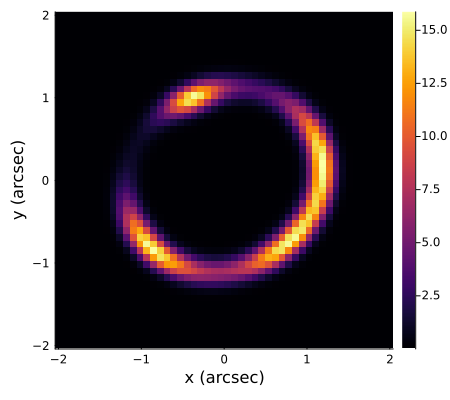

In [275]:
LensedLight = LensBase.LensRayShooting(xg, yg; LensModel=NIE, LensKwargs=mean_param
                            ,SourceProfile=GaussianLight.GaussianSphere,SourceKwargs=LightParaDict);

L3 = Plots.heatmap(x, x, LensedLight, size=(450,400), colorbar=true, xlabel="x (arcsec)", ylabel="y (arcsec)")

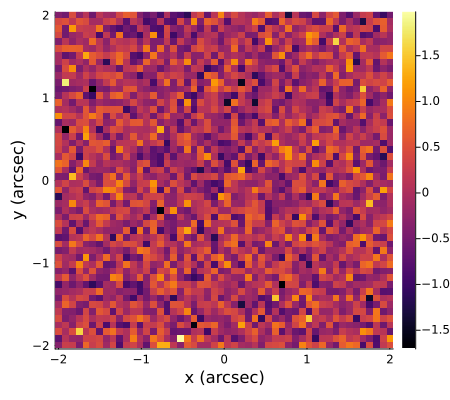

In [276]:
res = LensedLight - data_obs
L4 = Plots.heatmap(x, x, res, size=(450,400), colorbar=true, xlabel="x (arcsec)", ylabel="y (arcsec)")

# Point source analysis

In [303]:
using NLsolve, SpecialFunctions

In [317]:
function test(x)
   gamma(3)-gamma(3,x)
end

test (generic function with 1 method)

In [326]:
nlsolve(test,[0.1])

MethodError: MethodError: no method matching gamma(::Int64, ::Vector{Float64})

Closest candidates are:
  gamma(::Integer, !Matched::Number)
   @ SpecialFunctions ~/.julia/packages/SpecialFunctions/50GLP/src/gamma_inc.jl:1115
  gamma(::Union{Int16, Int32, Int64, Int8, UInt16, UInt32, UInt64, UInt8})
   @ SpecialFunctions ~/.julia/packages/SpecialFunctions/50GLP/src/gamma.jl:569
  gamma(::Number)
   @ SpecialFunctions ~/.julia/packages/SpecialFunctions/50GLP/src/gamma.jl:567
  ...


In [321]:
typeof(gamma)

typeof(gamma) (singleton type of function gamma, subtype of Function)